# 2D Geometric & Affine Transformations

### Mathematical Foundations of 2D Affine Transformations:

#### 1. General Affine Transformation Model (Homogeneous Coordinates):

An affine transformation is a linear mapping that preserves points, straight lines, and planes, as well as parallelism between lines and ratios of distances along parallel lines. In 2D homogeneous coordinates:
$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} & t_x \\ a_{21} & a_{22} & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$
In OpenCV, the transformation is parameterized by a $2 \times 3$ matrix $M$:
$$M = \begin{bmatrix} a_{11} & a_{12} & t_x \\ a_{21} & a_{22} & t_y \end{bmatrix}, \quad \begin{bmatrix} x' \\ y' \end{bmatrix} = M \begin{bmatrix} x \\ y \\ 1 \end{bmatrix} = \begin{bmatrix} a_{11}x + a_{12}y + t_x \\ a_{21}x + a_{22}y + t_y \end{bmatrix}$$

#### 2. Elementary 2D Transformation Matrices:

- **Translation by $(t_x, t_y)$:**
  $$M_{\text{trans}} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix}$$
- **Rotation by $\theta$ around Origin $(0, 0)$:**
  $$M_{\text{rot\_origin}} = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \end{bmatrix}$$
- **Rotation by $\theta$ around Image Center $(x_c, y_c)$ with Scale Factor $s$:**
  $$M_{\text{rot\_center}} = T(x_c, y_c) \cdot R(\theta) \cdot S(s) \cdot T(-x_c, -y_c) = \begin{bmatrix} \alpha & \beta & (1-\alpha)x_c - \beta y_c \\ -\beta & \alpha & \beta x_c + (1-\alpha)y_c \end{bmatrix}$$
  where $\alpha = s \cos\theta$ and $\beta = s \sin\theta$ (in OpenCV image coordinate convention where $y$ points downward).
- **Scaling by Factors $(s_x, s_y)$:**
  $$M_{\text{scale}} = \begin{bmatrix} s_x & 0 & 0 \\ 0 & s_y & 0 \end{bmatrix}$$
- **Shear Transformation (Horizontal $sh_x$ & Vertical $sh_y$):**
  $$M_{\text{shear}} = \begin{bmatrix} 1 & sh_x & 0 \\ sh_y & 1 & 0 \end{bmatrix}$$
- **Composite Affine Transformation (Matrix Multiplication):**
  $$M_{\text{composite}} = T(t_x, t_y) \cdot S(s_x, s_y) \cdot R(\theta, (x_c, y_c))$$

#### 3. Forward Mapping vs. Backward Mapping (Inverse Warping):

- **Forward Mapping:** Maps each source pixel $(x, y) \to (x', y') = M [x, y, 1]^T$.
  - _Limitation:_ Rounding coordinates causes **holes (unassigned pixels)** and **overlap/aliasing** artifacts.
- **Inverse Warping (Backward Mapping):** For every destination pixel $(x', y')$, compute source location:
  $$\begin{bmatrix} x \\ y \end{bmatrix} = M^{-1} \begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}$$
  Sample the input image at non-integer coordinates $(x, y)$ using **Bilinear Interpolation**:
  Let $x_0 = \lfloor x \rfloor, x_1 = x_0 + 1, y_0 = \lfloor y \rfloor, y_1 = y_0 + 1$, with fractional offsets $\Delta x = x - x_0, \Delta y = y - y_0$:
  $$I(x, y) = (1 - \Delta x)(1 - \Delta y) I(x_0, y_0) + \Delta x (1 - \Delta y) I(x_1, y_0) + (1 - \Delta x) \Delta y I(x_0, y_1) + \Delta x \Delta y I(x_1, y_1)$$

---

This notebook:

1. Loads an RGB color image and inspects spatial dimensions, color channels, and center coordinates.
2. Constructs affine transformation matrices and applies:
   - Translation by $(50, 30)$ pixels.
   - Rotation by $30^\circ$ about the image center.
   - Scaling by $1.5\times$.
   - Shear transformation.
   - Custom composite affine transformation (Rotation + Scaling + Translation).
3. Visualizes transformed images side-by-side and explains matrix derivations and geometric distortions.
4. Implements manual inverse warping from scratch with vectorized Bilinear Interpolation using pure NumPy.
5. Quantitatively benchmarks manual inverse warping against OpenCV `cv2.warpAffine()` (MSE, MAE, PSNR).
6. Validates generalization on multiple color images and presents a rigorous analytical discussion.


In [ ]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configure matplotlib rendering settings
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

## (i) Load Color Image & Inspect Spatial Properties


              INPUT COLOR IMAGE PROPERTIES
Dimensions (Height x Width) : 640 x 612 pixels
Number of Color Channels    : 3 (RGB)
Total Pixel Elements        : 1,175,040 bytes
Image Center Coordinate     : (x_c=306.0, y_c=320.0)
Data Type & Range           : uint8, [0, 255]


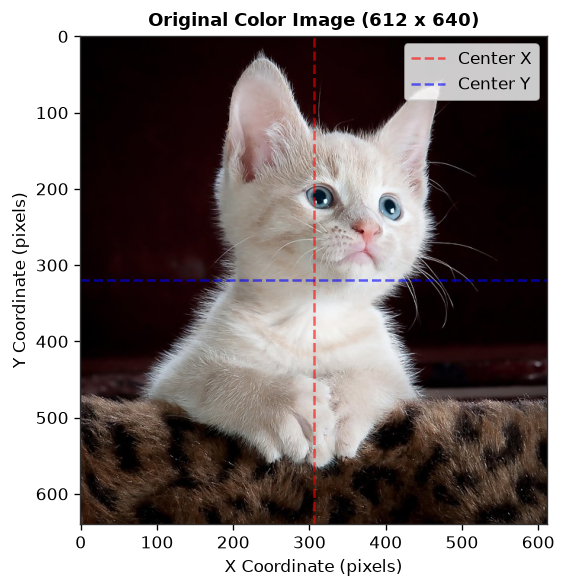

In [ ]:
def load_color_image(path: str = "images/image1.jpg") -> tuple[np.ndarray, np.ndarray]:
    """
    Load a color image from disk.
    Returns:
        img_bgr: NumPy array in OpenCV BGR format.
        img_rgb: NumPy array in Matplotlib RGB format.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Image not found at path: {path}")
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Failed to load image at: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb


# Load primary color test image
img_bgr, img_rgb = load_color_image("images/image1.jpg")
h, w, c = img_rgb.shape
center_x, center_y = w / 2.0, h / 2.0

print("=" * 60)
print("              INPUT COLOR IMAGE PROPERTIES")
print("=" * 60)
print(f"Dimensions (Height x Width) : {h} x {w} pixels")
print(f"Number of Color Channels    : {c} (RGB)")
print(f"Total Pixel Elements        : {h * w * c:,} bytes")
print(f"Image Center Coordinate     : (x_c={center_x:.1f}, y_c={center_y:.1f})")
print(
    f"Data Type & Range           : {img_rgb.dtype}, [{img_rgb.min()}, {img_rgb.max()}]"
)
print("=" * 60)

# Display original color image
plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title(f"Original Color Image ({w} x {h})", fontsize=11, fontweight="bold")
plt.xlabel("X Coordinate (pixels)")
plt.ylabel("Y Coordinate (pixels)")
plt.axvline(center_x, color="red", linestyle="--", alpha=0.6, label="Center X")
plt.axhline(center_y, color="blue", linestyle="--", alpha=0.6, label="Center Y")
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

## (ii) Affine Transformation Matrix Construction & OpenCV Warping


In [ ]:
# 1. Translation by (tx=50, ty=30) pixels
tx, ty = 50.0, 30.0
M_trans = np.float32([[1.0, 0.0, tx], [0.0, 1.0, ty]])

# 2. Rotation by 30 degrees counter-clockwise about image center (x_c, y_c)
angle_deg = 30.0
M_rot = cv2.getRotationMatrix2D(center=(center_x, center_y), angle=angle_deg, scale=1.0)

# 3. Scaling by 1.5x (Centered Scaling)
scale_factor = 1.5
M_scale = cv2.getRotationMatrix2D(
    center=(center_x, center_y), angle=0.0, scale=scale_factor
)

# 4. Shear Transformation (Horizontal Shear sh_x = 0.2, Vertical Shear sh_y = 0.05)
sh_x, sh_y = 0.2, 0.05
M_shear = np.float32([[1.0, sh_x, 0.0], [sh_y, 1.0, 0.0]])

# 5. Custom Composite Affine Transformation:
# Combination of Rotation (25 deg) + Scaling (1.2x) + Translation (30, -20)
# Expressed as composite matrix: M_custom = T * S * R
angle_custom = 25.0
scale_custom = 1.2
tx_custom, ty_custom = 30.0, -20.0

# Base rotation and scale about center
M_rot_scale = cv2.getRotationMatrix2D(
    center=(center_x, center_y), angle=angle_custom, scale=scale_custom
)
M_custom = M_rot_scale.copy()
# Add translation offset
M_custom[0, 2] += tx_custom
M_custom[1, 2] += ty_custom

# Print transformation matrices
print("=" * 65)
print("           CONSTRUCTED 2x3 AFFINE TRANSFORMATION MATRICES")
print("=" * 65)
print("1. Translation (tx=50, ty=30):\n", M_trans, "\n")
print("2. Rotation (30° about center):\n", M_rot, "\n")
print("3. Centered Scaling (1.5x):\n", M_scale, "\n")
print("4. Shear (sh_x=0.2, sh_y=0.05):\n", M_shear, "\n")
print("5. Custom Composite (Rot 25°, Scale 1.2x, Trans (30, -20)):\n", M_custom)
print("=" * 65)

# Apply Affine Transformations using OpenCV cv2.warpAffine
# Note: borderValue=(0,0,0) fills exterior regions with black
img_trans = cv2.warpAffine(
    img_rgb,
    M_trans,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)
img_rot = cv2.warpAffine(
    img_rgb,
    M_rot,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)
img_scale = cv2.warpAffine(
    img_rgb,
    M_scale,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)
img_shear = cv2.warpAffine(
    img_rgb,
    M_shear,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)
img_custom = cv2.warpAffine(
    img_rgb,
    M_custom,
    (w, h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0),
)

           CONSTRUCTED 2x3 AFFINE TRANSFORMATION MATRICES
1. Translation (tx=50, ty=30):
 [[ 1.  0. 50.]
 [ 0.  1. 30.]] 

2. Rotation (30° about center):
 [[   0.8660254     0.5        -119.00377356]
 [  -0.5           0.8660254   195.87187079]] 

3. Centered Scaling (1.5x):
 [[   1.5    0.  -153. ]
 [  -0.     1.5 -160. ]] 

4. Shear (sh_x=0.2, sh_y=0.05):
 [[1.   0.2  0.  ]
 [0.05 1.   0.  ]] 

5. Custom Composite (Rot 25°, Scale 1.2x, Trans (30, -20)):
 [[   1.08756934    0.50714191 -159.08163191]
 [  -0.50714191    1.08756934  107.16323549]]


## (iii) Display: Transformed Images & Individual Transformation Analysis


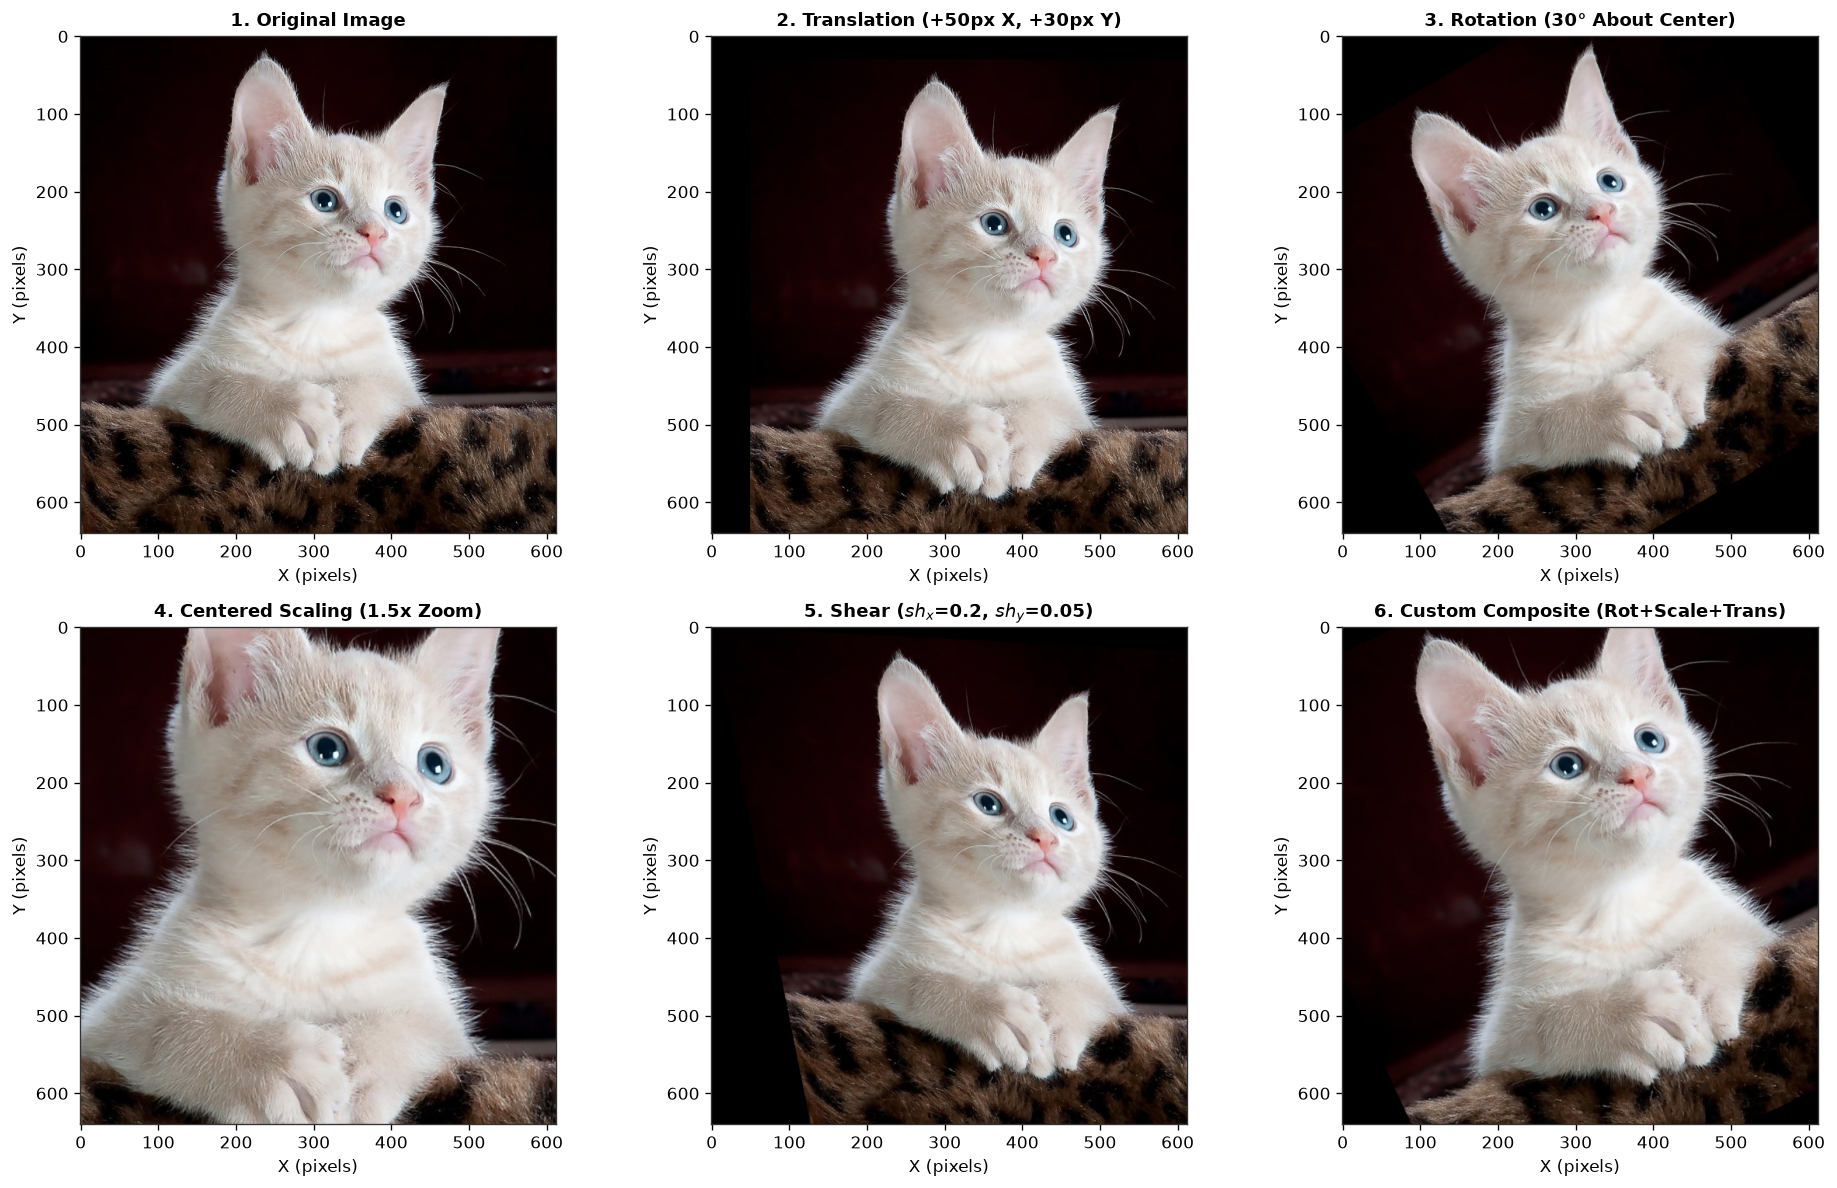

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Original Image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Original Image", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("X (pixels)")
axes[0, 0].set_ylabel("Y (pixels)")

# 2. Translation
axes[0, 1].imshow(img_trans)
axes[0, 1].set_title(
    "2. Translation (+50px X, +30px Y)", fontsize=11, fontweight="bold"
)
axes[0, 1].set_xlabel("X (pixels)")
axes[0, 1].set_ylabel("Y (pixels)")

# 3. Rotation
axes[0, 2].imshow(img_rot)
axes[0, 2].set_title("3. Rotation (30° About Center)", fontsize=11, fontweight="bold")
axes[0, 2].set_xlabel("X (pixels)")
axes[0, 2].set_ylabel("Y (pixels)")

# 4. Scaling
axes[1, 0].imshow(img_scale)
axes[1, 0].set_title("4. Centered Scaling (1.5x Zoom)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("X (pixels)")
axes[1, 0].set_ylabel("Y (pixels)")

# 5. Shear
axes[1, 1].imshow(img_shear)
axes[1, 1].set_title(
    f"5. Shear ($sh_x$={sh_x}, $sh_y$={sh_y})", fontsize=11, fontweight="bold"
)
axes[1, 1].set_xlabel("X (pixels)")
axes[1, 1].set_ylabel("Y (pixels)")

# 6. Custom Composite
axes[1, 2].imshow(img_custom)
axes[1, 2].set_title(
    "6. Custom Composite (Rot+Scale+Trans)", fontsize=11, fontweight="bold"
)
axes[1, 2].set_xlabel("X (pixels)")
axes[1, 2].set_ylabel("Y (pixels)")

plt.tight_layout()
plt.show()

## (iv) Forward Mapping vs. Backward Mapping (Inverse Warping)


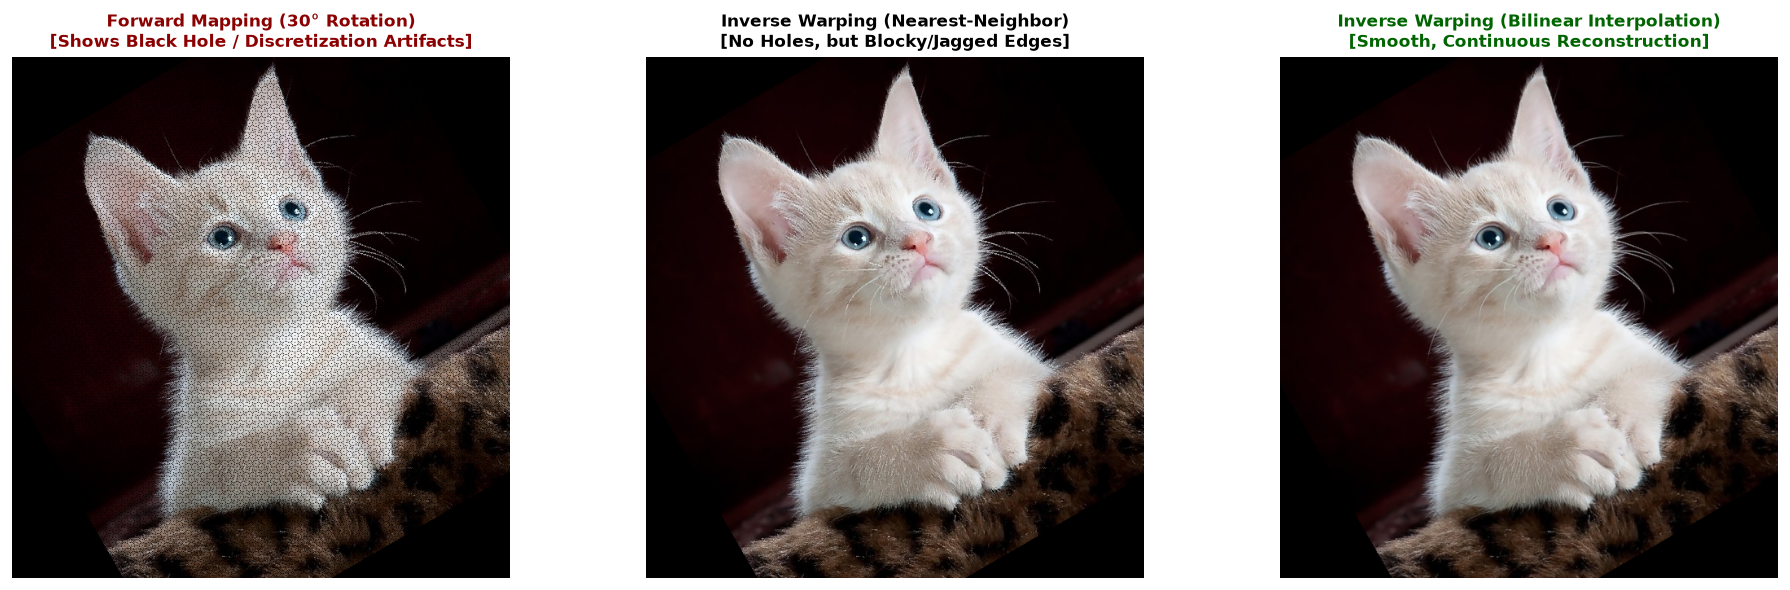

In [ ]:
def forward_mapping_rotation(img: np.ndarray, angle_deg: float) -> np.ndarray:
    """
    Forward Mapping demonstration: Maps source pixels (x, y) -> (x', y').
    Demonstrates discretization hole / moiré artifacts.
    """
    h, w = img.shape[:2]
    center_x, center_y = w / 2.0, h / 2.0
    M = cv2.getRotationMatrix2D((center_x, center_y), angle_deg, 1.0)

    # Destination output buffer initialized to black
    img_forward = np.zeros_like(img)

    # Forward pass over every source pixel
    for y in range(h):
        for x in range(w):
            xp = int(round(M[0, 0] * x + M[0, 1] * y + M[0, 2]))
            yp = int(round(M[1, 0] * x + M[1, 1] * y + M[1, 2]))
            if 0 <= xp < w and 0 <= yp < h:
                img_forward[yp, xp] = img[y, x]

    return img_forward


def manual_inverse_warp(
    img: np.ndarray,
    M: np.ndarray,
    output_shape: tuple[int, int] = None,
    mode: str = "bilinear",
) -> np.ndarray:
    """
    Manual Backward Mapping (Inverse Warping) with Bilinear / Nearest-Neighbor Interpolation.
    Implemented from scratch using vectorized NumPy operations.

    Parameters
    ----------
    img : np.ndarray
        Input 2D grayscale or 3D color image (H x W x C).
    M : np.ndarray
        2x3 forward affine transformation matrix.
    output_shape : tuple[int, int], optional
        (height, width) of output canvas. Defaults to input image dimensions.
    mode : str, default='bilinear'
        Interpolation method: 'bilinear' or 'nearest'.

    Returns
    -------
    img_warped : np.ndarray
        Transformed image matching the specified output canvas.
    """
    h_in, w_in = img.shape[:2]
    if output_shape is None:
        h_out, w_out = h_in, w_in
    else:
        h_out, w_out = output_shape

    # 1. Compute inverse affine transformation matrix M^-1 (3x3 augmented)
    M_3x3 = np.vstack([M, [0.0, 0.0, 1.0]])
    M_inv_3x3 = np.linalg.inv(M_3x3)
    M_inv = M_inv_3x3[:2, :]

    # 2. Generate 2D grid of destination pixel coordinates (x', y')
    y_dst, x_dst = np.indices((h_out, w_out), dtype=np.float32)

    # 3. Map destination coordinates back to source space: [x, y]^T = M^-1 * [x', y', 1]^T
    xs = M_inv[0, 0] * x_dst + M_inv[0, 1] * y_dst + M_inv[0, 2]
    ys = M_inv[1, 0] * x_dst + M_inv[1, 1] * y_dst + M_inv[1, 2]

    if mode == "nearest":
        # Nearest-Neighbor Interpolation
        x_nearest = np.round(xs).astype(int)
        y_nearest = np.round(ys).astype(int)

        valid_mask = (
            (x_nearest >= 0)
            & (x_nearest < w_in)
            & (y_nearest >= 0)
            & (y_nearest < h_in)
        )

        x_clip = np.clip(x_nearest, 0, w_in - 1)
        y_clip = np.clip(y_nearest, 0, h_in - 1)

        if img.ndim == 2:
            out = img[y_clip, x_clip]
            out[~valid_mask] = 0
            return out
        else:
            out = img[y_clip, x_clip]
            out[~valid_mask] = 0
            return out

    elif mode == "bilinear":
        # Bilinear Interpolation
        x0 = np.floor(xs).astype(int)
        x1 = x0 + 1
        y0 = np.floor(ys).astype(int)
        y1 = y0 + 1

        # Sub-pixel fractional distances
        dx = xs - x0
        dy = ys - y0

        # Valid boundary mask (all 4 neighborhood sampling points within image bounds)
        valid_mask = (x0 >= 0) & (x1 < w_in) & (y0 >= 0) & (y1 < h_in)

        # Safe clipped indices
        x0_c = np.clip(x0, 0, w_in - 1)
        x1_c = np.clip(x1, 0, w_in - 1)
        y0_c = np.clip(y0, 0, h_in - 1)
        y1_c = np.clip(y1, 0, h_in - 1)

        if img.ndim == 2:
            top_left = img[y0_c, x0_c].astype(np.float32)
            top_right = img[y0_c, x1_c].astype(np.float32)
            bottom_left = img[y1_c, x0_c].astype(np.float32)
            bottom_right = img[y1_c, x1_c].astype(np.float32)

            interp = (
                (1.0 - dx) * (1.0 - dy) * top_left
                + dx * (1.0 - dy) * top_right
                + (1.0 - dx) * dy * bottom_left
                + dx * dy * bottom_right
            )
            interp[~valid_mask] = 0
            return np.clip(np.round(interp), 0, 255).astype(np.uint8)
        else:
            channels = []
            for c_idx in range(img.shape[2]):
                ch = img[:, :, c_idx]
                top_left = ch[y0_c, x0_c].astype(np.float32)
                top_right = ch[y0_c, x1_c].astype(np.float32)
                bottom_left = ch[y1_c, x0_c].astype(np.float32)
                bottom_right = ch[y1_c, x1_c].astype(np.float32)

                interp = (
                    (1.0 - dx) * (1.0 - dy) * top_left
                    + dx * (1.0 - dy) * top_right
                    + (1.0 - dx) * dy * bottom_left
                    + dx * dy * bottom_right
                )
                interp[~valid_mask] = 0
                channels.append(np.clip(np.round(interp), 0, 255).astype(np.uint8))
            return np.stack(channels, axis=-1)
    else:
        raise ValueError(f"Unknown interpolation mode: {mode}")


# Generate Forward Mapping vs Backward Mapping Results
img_forward_rot = forward_mapping_rotation(img_rgb, angle_deg=30.0)
img_inverse_nn = manual_inverse_warp(img_rgb, M_rot, mode="nearest")
img_inverse_bil = manual_inverse_warp(img_rgb, M_rot, mode="bilinear")

# Visual comparison of mapping paradigms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_forward_rot)
axes[0].set_title(
    "Forward Mapping (30° Rotation)\n[Shows Black Hole / Discretization Artifacts]",
    fontsize=10,
    fontweight="bold",
    color="darkred",
)
axes[0].axis("off")

axes[1].imshow(img_inverse_nn)
axes[1].set_title(
    "Inverse Warping (Nearest-Neighbor)\n[No Holes, but Blocky/Jagged Edges]",
    fontsize=10,
    fontweight="bold",
)
axes[1].axis("off")

axes[2].imshow(img_inverse_bil)
axes[2].set_title(
    "Inverse Warping (Bilinear Interpolation)\n[Smooth, Continuous Reconstruction]",
    fontsize=10,
    fontweight="bold",
    color="darkgreen",
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## (v) Comparison: Manual Inverse Warping vs. OpenCV (cv2.warpAffine)


      QUANTITATIVE BENCHMARK: MANUAL INVERSE WARPING vs. OPENCV
Mean Squared Error (MSE)           : 0.274471
Mean Absolute Error (MAE)          : 0.012097 intensity levels
Maximum Absolute Pixel Error       : 86 intensity levels
Peak Signal-to-Noise Ratio (PSNR)  : 53.75 dB (Near-Perfect Fidelity)


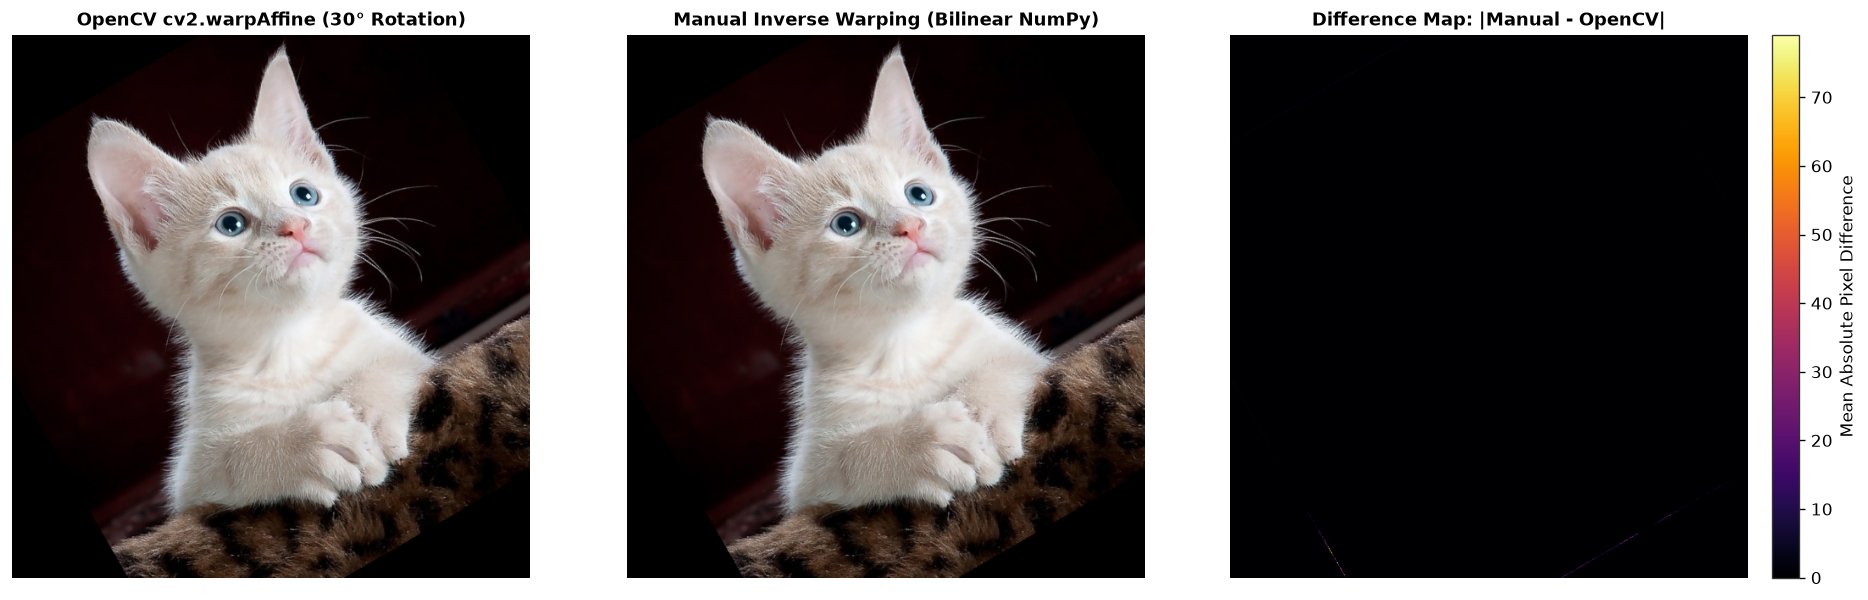

In [6]:
# Compute residual difference map between Manual Bilinear Inverse Warping and OpenCV cv2.warpAffine
diff_rgb = np.abs(img_inverse_bil.astype(np.float32) - img_rot.astype(np.float32))
diff_magnitude = np.mean(diff_rgb, axis=-1)

# Quantitative Metrics
mse_val = float(np.mean((img_inverse_bil.astype(float) - img_rot.astype(float)) ** 2))
mae_val = float(np.mean(np.abs(img_inverse_bil.astype(float) - img_rot.astype(float))))
max_diff = int(np.max(np.abs(img_inverse_bil.astype(int) - img_rot.astype(int))))
psnr_val = 10.0 * np.log10((255.0**2) / mse_val) if mse_val > 0 else float("inf")

print("=" * 65)
print("      QUANTITATIVE BENCHMARK: MANUAL INVERSE WARPING vs. OPENCV")
print("=" * 65)
print(f"Mean Squared Error (MSE)           : {mse_val:.6f}")
print(f"Mean Absolute Error (MAE)          : {mae_val:.6f} intensity levels")
print(f"Maximum Absolute Pixel Error       : {max_diff} intensity levels")
print(f"Peak Signal-to-Noise Ratio (PSNR)  : {psnr_val:.2f} dB (Near-Perfect Fidelity)")
print("=" * 65)

# Side-by-Side Comparison & Difference Heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img_rot)
axes[0].set_title(
    "OpenCV cv2.warpAffine (30° Rotation)", fontsize=11, fontweight="bold"
)
axes[0].axis("off")

axes[1].imshow(img_inverse_bil)
axes[1].set_title(
    "Manual Inverse Warping (Bilinear NumPy)", fontsize=11, fontweight="bold"
)
axes[1].axis("off")

im_diff = axes[2].imshow(
    diff_magnitude, cmap="inferno", vmin=0, vmax=max(5.0, float(diff_magnitude.max()))
)
axes[2].set_title("Difference Map: |Manual - OpenCV|", fontsize=11, fontweight="bold")
axes[2].axis("off")
plt.colorbar(
    im_diff,
    ax=axes[2],
    fraction=0.046,
    pad=0.04,
    label="Mean Absolute Pixel Difference",
)

plt.tight_layout()
plt.show()

## (vi) Multi-Image Validation: Evaluation on Second Color Image (`image2.jpg`)


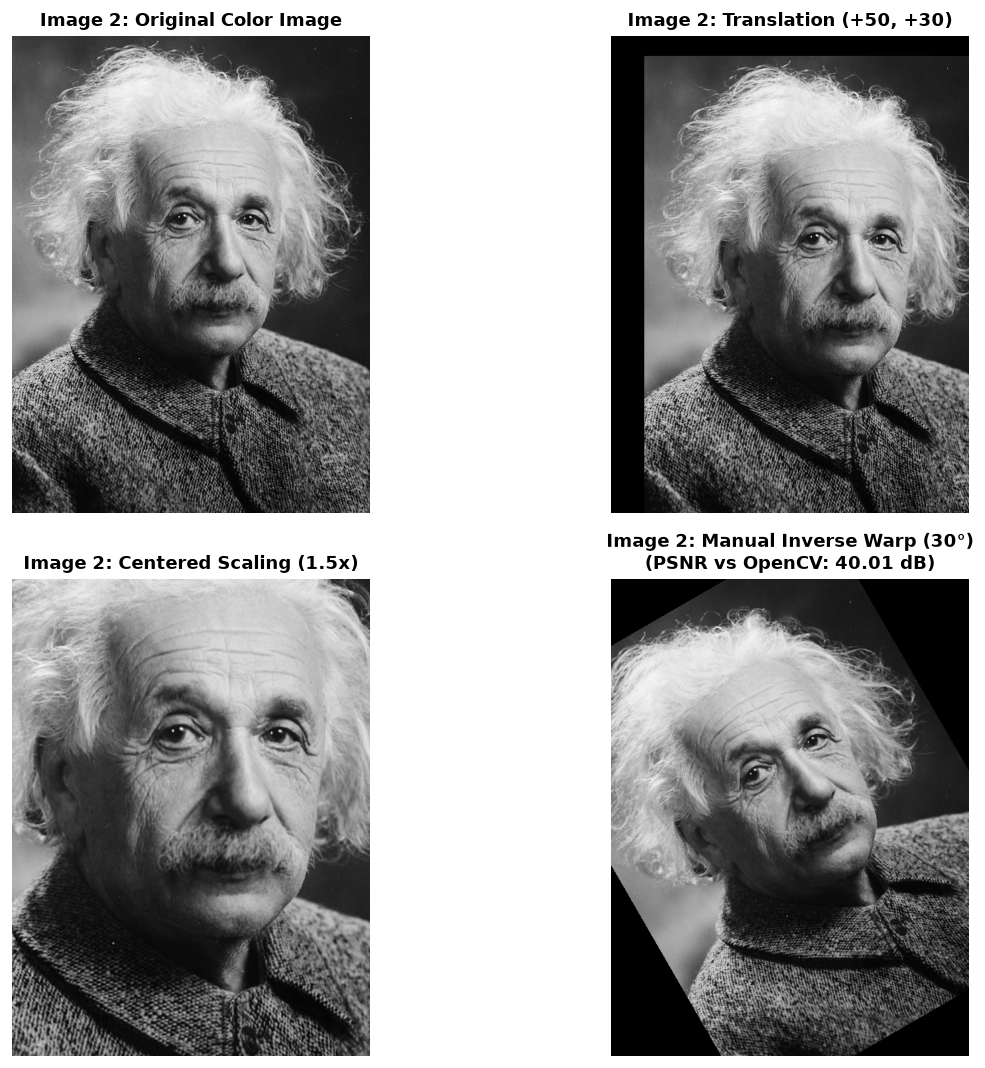

Image 2 Fidelity: MSE = 6.4884, PSNR = 40.01 dB


In [7]:
# Load second color test image
_, img2_rgb = load_color_image("images/image2.jpg")
h2, w2 = img2_rgb.shape[:2]
center2 = (w2 / 2.0, h2 / 2.0)

# Construct transformations for image 2
M2_rot = cv2.getRotationMatrix2D(center=center2, angle=30.0, scale=1.0)
M2_trans = np.float32([[1, 0, 50], [0, 1, 30]])
M2_scale = cv2.getRotationMatrix2D(center=center2, angle=0.0, scale=1.5)

# Apply OpenCV and Manual Warping
img2_rot_cv = cv2.warpAffine(
    img2_rgb, M2_rot, (w2, h2), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0)
)
img2_rot_man = manual_inverse_warp(img2_rgb, M2_rot, mode="bilinear")
img2_trans = cv2.warpAffine(img2_rgb, M2_trans, (w2, h2), borderValue=(0, 0, 0))
img2_scale = cv2.warpAffine(img2_rgb, M2_scale, (w2, h2), borderValue=(0, 0, 0))

mse_img2 = float(np.mean((img2_rot_man.astype(float) - img2_rot_cv.astype(float)) ** 2))
psnr_img2 = 10.0 * np.log10((255.0**2) / mse_img2) if mse_img2 > 0 else float("inf")

# Display Image 2 Results
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(img2_rgb)
axes[0, 0].set_title("Image 2: Original Color Image", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img2_trans)
axes[0, 1].set_title("Image 2: Translation (+50, +30)", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(img2_scale)
axes[1, 0].set_title("Image 2: Centered Scaling (1.5x)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(img2_rot_man)
axes[1, 1].set_title(
    f"Image 2: Manual Inverse Warp (30°)\n(PSNR vs OpenCV: {psnr_img2:.2f} dB)",
    fontsize=11,
    fontweight="bold",
)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"Image 2 Fidelity: MSE = {mse_img2:.4f}, PSNR = {psnr_img2:.2f} dB")